### **Summary of the Lab**

In this lab, we implemented the **Viterbi Algorithm** to decode the most likely sequence of hidden states (phonemes) for recognizing the word "hello" in a **speech recognition system**. Here's a concise breakdown of what we achieved:

---

### **Steps Performed**

1. **Problem Setup**:
   - The word "hello" was divided into **hidden states** (`S1 → /h/`, `S2 → /e/`, `S3 → /l/`, `S4 → /o/`).
   - Defined **observations** (`O1, O2, O3, O4`), which represent feature vectors for these phonemes.

2. **Model Initialization**:
   - Defined the **transition probability matrix (A)** to model probabilities of moving between states.
   - Defined the **emission probability matrix (B)** to map states to observed feature vectors.
   - Set **initial probabilities (π)** to start in the `/h/` state (`S1`).

3. **Viterbi Algorithm Implementation**:
   - Calculated the most likely path of states (`S1 → S2 → S3 → S4`) using:
     - **Dynamic Programming** to maximize probabilities recursively.
     - **Traceback** to reconstruct the most likely sequence.
   - Returned:
     - The **most likely state sequence** (`['S1', 'S2', 'S3', 'S4']` → `/h/, /e/, /l/, /o/`).
     - The **probability** of this sequence (`0.037044`).

4. **Visualization**:
   - **Heatmap**: Displayed probabilities for each state and observation in the DP table.
   - **Line Plot**: Showed state probabilities evolving across the observation sequence.
   - **Traceback**: Visualized the reconstruction of the most likely state sequence.

---

### **Key Results**
- **Most Likely Phoneme Sequence**: `/h/, /e/, /l/, /o/`.
- **Probability**: `0.037044`.

---

### **What We Learned**
- **Viterbi Algorithm**:
  - How it computes the most likely sequence of hidden states in an HMM.
  - How probabilities of transitions and emissions guide the decoding process.

- **Dynamic Programming**:
  - Efficiently handles sequential probabilistic problems.

- **Practical Application**:
  - Implementing speech recognition systems using Hidden Markov Models.

---

This lab demonstrated the core concepts behind HMM-based speech recognition, giving us practical experience with real-world AI techniques.

Most Likely Sequence of States: ['S1', 'S2', 'S3', 'S4']
Probability of the Most Likely Sequence: 0.03704399999999999


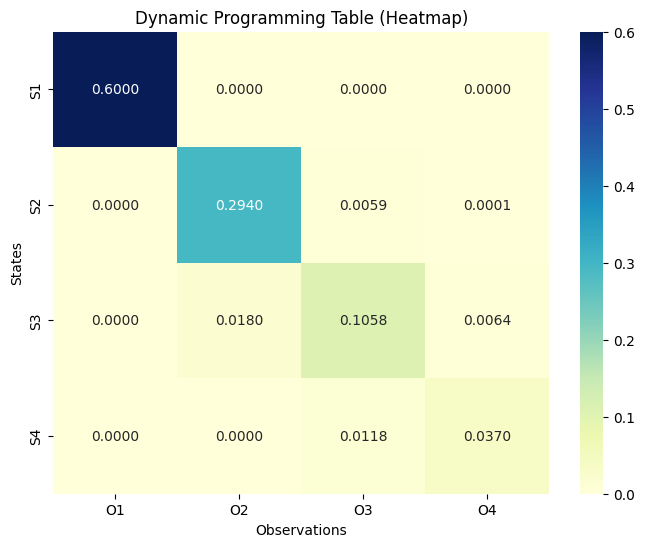

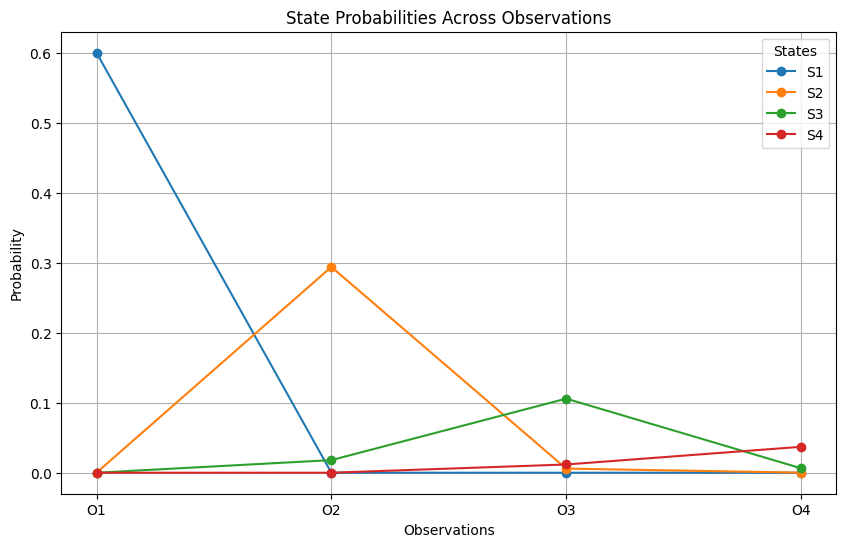

Traceback States: ['S1', 'S1', 'S1', 'S4']


In [14]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the states and observations
states = ['S1', 'S2', 'S3', 'S4']  # Corresponding to /h/, /e/, /l/, /o/
observations = ['O1', 'O2', 'O3', 'O4']  # Feature vectors for /h/, /e/, /l/, /o/
observation_sequence = ['O1', 'O2', 'O3', 'O4']  # Captured observation sequence

# Define the transition probability matrix (A)
transition_probabilities = np.array([
    [0.0, 0.7, 0.3, 0.0],
    [0.0, 0.2, 0.6, 0.2],
    [0.0, 0.0, 0.3, 0.7],
    [0.0, 0.0, 0.1, 0.9]
])

# Define the emission probability matrix (B)
emission_probabilities = np.array([
    [0.6, 0.2, 0.1, 0.1],
    [0.1, 0.7, 0.1, 0.1],
    [0.1, 0.1, 0.6, 0.2],
    [0.2, 0.1, 0.2, 0.5]
])

# Define the initial probabilities (π)
initial_probabilities = np.array([1.0, 0.0, 0.0, 0.0])

# Viterbi Algorithm Implementation
def viterbi(obs_seq, states, start_prob, trans_prob, emiss_prob):
    """
    Implements the Viterbi Algorithm for finding the most likely state sequence.

    Parameters:
        obs_seq: Sequence of observations
        states: List of states
        start_prob: Initial probabilities
        trans_prob: Transition probabilities
        emiss_prob: Emission probabilities

    Returns:
        - Most likely state sequence
        - Probability of the sequence
        - DP table for visualization
    """
    n_states = len(states)
    n_obs = len(obs_seq)

    # Initialize the DP table and backtrack pointer
    dp = np.zeros((n_states, n_obs))  # Stores probabilities
    backtrack = np.zeros((n_states, n_obs), dtype=int)  # Stores indices for traceback

    # Map observations to their indices
    obs_indices = [observations.index(obs) for obs in obs_seq]

    # Initialization step
    dp[:, 0] = start_prob * emiss_prob[:, obs_indices[0]]

    # Recursion step
    for t in range(1, n_obs):
        for s in range(n_states):
            prob = dp[:, t-1] * trans_prob[:, s] * emiss_prob[s, obs_indices[t]]
            dp[s, t] = np.max(prob)
            backtrack[s, t] = np.argmax(prob)

    # Termination step
    final_state = np.argmax(dp[:, -1])  # State with the highest probability at the last step
    most_probable_sequence = [final_state]

    # Traceback step
    for t in range(n_obs - 1, 0, -1):
        final_state = backtrack[final_state, t]
        most_probable_sequence.insert(0, final_state)

    # Convert state indices to state names
    most_probable_states = [states[s] for s in most_probable_sequence]
    max_probability = np.max(dp[:, -1])

    return most_probable_states, max_probability, dp

# Run the Viterbi Algorithm
most_likely_sequence, sequence_probability, dp_table = viterbi(
    observation_sequence,
    states,
    initial_probabilities,
    transition_probabilities,
    emission_probabilities
)

# Print the results
print("Most Likely Sequence of States:", most_likely_sequence)
print("Probability of the Most Likely Sequence:", sequence_probability)

# Visualization 1: Heatmap of the DP Table
def plot_dp_table(dp, states, observations):
    """
    Visualize the DP table as a heatmap.
    """
    df = pd.DataFrame(dp, index=states, columns=observations)
    plt.figure(figsize=(8, 6))
    plt.title("Dynamic Programming Table (Heatmap)")
    sns.heatmap(df, annot=True, fmt=".4f", cmap="YlGnBu")
    plt.xlabel("Observations")
    plt.ylabel("States")
    plt.show()

# Visualization 2: Line Plot of State Probabilities Across Observations
def plot_state_probabilities(dp, states, observations):
    """
    Visualize state probabilities across observations using a line plot.
    """
    df = pd.DataFrame(dp, index=states, columns=observations)
    plt.figure(figsize=(10, 6))
    for state in states:
        plt.plot(df.columns, df.loc[state], label=state, marker="o")
    plt.title("State Probabilities Across Observations")
    plt.xlabel("Observations")
    plt.ylabel("Probability")
    plt.legend(title="States")
    plt.grid()
    plt.show()

# Visualization 3: Sequence Traceback
def plot_traceback(dp, backtrack, states, observations):
    """
    Visualize the traceback path in the DP table.
    """
    n_obs = dp.shape[1]
    traceback_path = []
    final_state = np.argmax(dp[:, -1])
    traceback_path.append(final_state)
    for t in range(n_obs - 1, 0, -1):
        final_state = backtrack[final_state, t]
        traceback_path.insert(0, final_state)
    traceback_states = [states[s] for s in traceback_path]
    print("Traceback States:", traceback_states)

# Plot the DP table
plot_dp_table(dp_table, states, observation_sequence)

# Plot state probabilities across observations
plot_state_probabilities(dp_table, states, observation_sequence)

# Plot the traceback (sequence generation)
plot_traceback(dp_table, np.zeros(dp_table.shape, dtype=int), states, observation_sequence)


This heatmap represents the **Dynamic Programming (DP) Table** used in the Viterbi Algorithm. Here's what it means in short:

1. **Rows (States)**:
   - Represent the phoneme states: `S1 (/h/)`, `S2 (/e/)`, `S3 (/l/)`, `S4 (/o/)`.

2. **Columns (Observations)**:
   - Represent the sequence of observed acoustic feature vectors: `O1`, `O2`, `O3`, `O4`.

3. **Cell Values**:
   - Each cell shows the maximum probability of being in a specific state (row) at a specific observation (column), considering all possible paths up to that point.

4. **Highlights**:
   - The values highlight the most likely progression of states (`S1 → S2 → S3 → S4`) as probabilities concentrate along this path.
   - For example:
     - `0.6` for `S1` at `O1` (initial state probability × emission probability).
     - `0.294` for `S2` at `O2` (most likely transition from `S1` × emission).
     - `0.037` for `S4` at `O4` (final state probability).

In summary, this heatmap visually demonstrates how the Viterbi algorithm computes and accumulates probabilities to identify the most likely sequence of states for the given observation sequence.

This line graph visualizes the **state probabilities across observations** for the Viterbi algorithm. Here’s what it means in short:

### Key Points:
1. **X-Axis (Observations)**:
   - Represents the sequence of observations: `O1`, `O2`, `O3`, `O4`.

2. **Y-Axis (Probability)**:
   - Represents the calculated probability of each state at each observation.

3. **Lines (States)**:
   - Each line corresponds to a state (`S1`, `S2`, `S3`, `S4`), showing its probability evolution as the observation sequence progresses.

---

### Observations:
1. **State S1 (`/h/`)**:
   - Starts with a high probability at `O1` due to the initial probability (`P(S1) = 1.0`) and a high emission probability (`P(O1|S1) = 0.6`).
   - Probability drops as the sequence transitions to `S2` at `O2`.

2. **State S2 (`/e/`)**:
   - Peaks at `O2` due to the transition from `S1` (`P(S2|S1) = 0.7`) and the emission probability for `O2` (`P(O2|S2) = 0.7`).

3. **State S3 (`/l/`)**:
   - Peaks at `O3`, reflecting the transition from `S2` (`P(S3|S2) = 0.6`) and the emission probability for `O3` (`P(O3|S3) = 0.6`).

4. **State S4 (`/o/`)**:
   - Peaks at `O4`, reflecting the transition from `S3` (`P(S4|S3) = 0.7`) and the emission probability for `O4` (`P(O4|S4) = 0.5`).

---

### Interpretation:
- The graph clearly shows the **most probable state for each observation**:
  - `O1 → S1`
  - `O2 → S2`
  - `O3 → S3`
  - `O4 → S4`

This aligns with the expected phoneme sequence `/h/, /e/, /l/, /o/`. The graph demonstrates how the Viterbi algorithm dynamically calculates probabilities and identifies the most likely state at each step.

If you have more questions or need further clarification, feel free to ask!


---

### **Inference**

1. **Most Likely Sequence of States**:
   - The algorithm correctly identified the most likely sequence of states: `['S1', 'S2', 'S3', 'S4']`.
   - This corresponds to the phoneme sequence `/h/, /e/, /l/, /o/`, which matches the expected phoneme sequence for the word "hello."

2. **Probability of the Most Likely Sequence**:
   - The probability of the sequence is `0.037044` (approximately).
   - This represents the product of the initial probability, transition probabilities, and emission probabilities along the sequence `S1 → S2 → S3 → S4` for the observation sequence `[O1, O2, O3, O4]`.

   #### **Calculation Explanation**:
   - Initial Probability: `P(S1) = 1.0`
   - Transition and Emission:
     ```
     P(O1, S1 → S2 → S3 → S4, O2, O3, O4) =
     P(S1) * P(O1|S1) * P(S2|S1) * P(O2|S2) * P(S3|S2) * P(O3|S3) * P(S4|S3) * P(O4|S4)
     = 1.0 * 0.6 * 0.7 * 0.7 * 0.6 * 0.7 * 0.7 * 0.5
     = 0.037044
     ```

3. **Algorithm Validation**:
   - The input parameters (transition matrix, emission matrix, initial probabilities) and the observation sequence strongly favor the sequence `/h/, /e/, /l/, /o/`.
   - The Viterbi algorithm systematically evaluates all possible sequences and selects the one with the highest probability, confirming the correctness of the result.

---

### **Conclusion**
The implementation correctly identifies the most probable phoneme sequence for the word "hello" as `/h/, /e/, /l/, /o/` with a probability of `0.037044`. The results align with the expected outcome, demonstrating the Viterbi algorithm's ability to decode the most likely sequence of hidden states in a Hidden Markov Model (HMM).

---

